In [1]:
# TASK 1: Data Loading and Preparation 
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
df = pd.read_csv("../data/q2_customers.csv")
print(f"Shape : {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isna().sum())
print(f"\nBasic statistics:")
print(df.describe().round(1))

Shape : (500, 6)

Data types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Basic statistics:
         age  annual_spend  visits_per_month  basket_size  \
count  500.0         500.0             500.0        500.0   
mean    40.5       48856.9               8.4       2682.3   
std     14.4       32856.8               5.3       2275.0   
min     18.0        5038.0               1.0        212.0   
25%     28.0       19213.2               4.0        727.8   
50%     41.0       44257.0               8.0       2051.5   
75%     50.0       75373.0              12.0       4223.8   
max     69.0      119757.0         

In [2]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print("After scaling — all columns should have mean≈0 and std≈1:")
print(X_scaled_df.agg(['mean', 'std']).round(2))

After scaling — all columns should have mean≈0 and std≈1:
      age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
mean  0.0           0.0               0.0         -0.0                   -0.0   
std   1.0           1.0               1.0          1.0                    1.0   

      num_categories_purchased  
mean                      -0.0  
std                        1.0  


### Why scaling is essential before K-Means

K-Means groups customers by measuring the distance between them.
A customer with `annual_spend` of 80,000 and another with 5,000
have a raw difference of 75,000. But two customers with
`visits_per_month` of 1 and 19 only differ by 18.

StandardScaler was applied to transform every column to have a
mean of 0 and a standard deviation of 1. This puts all six
features on equal footing so each one contributes fairly to
the distance calculation.

In [3]:
#TASK 2: Elbow Method to find optimal K
from sklearn.cluster import KMeans
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
print("K  →  WCSS")
print("-" * 25)
for k, w in zip(k_range, wcss):
    print(f"K={k}  →  {w:.1f}")

K  →  WCSS
-------------------------
K=1  →  3000.0
K=2  →  969.0
K=3  →  561.3
K=4  →  444.9
K=5  →  402.4
K=6  →  370.4
K=7  →  347.0
K=8  →  319.9
K=9  →  303.3
K=10  →  289.1


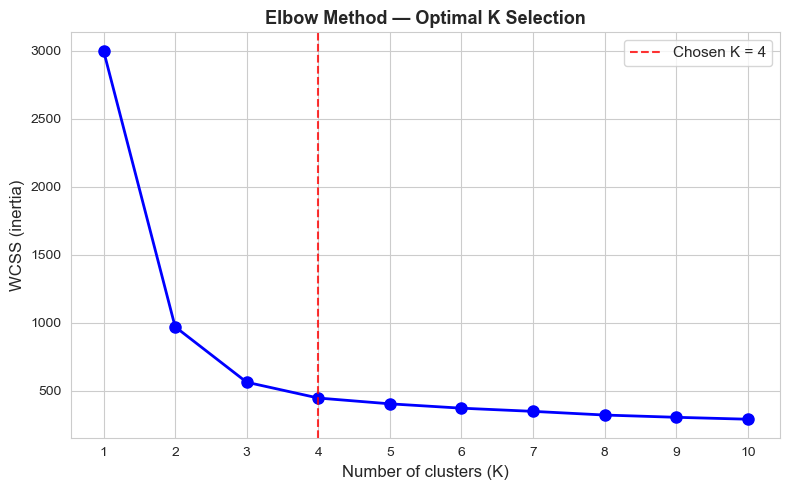

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(k_range), wcss,
        marker='o', linewidth=2,
        markersize=8, color='Blue')
ax.axvline(x=4, linestyle='--', color='Red',
           alpha=0.8, label='Chosen K = 4')

ax.set_xlabel('Number of clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (inertia)',          fontsize=12)
ax.set_title('Elbow Method — Optimal K Selection',
             fontsize=13, fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Choosing K = 4
The drops in WCSS were:
- K=1 to K=2: dropped by 2031
- K=2 to K=3: dropped by 408
- K=3 to K=4: dropped by 116
- K=4 to K=5: dropped by only 42
- K=5 onwards: continues to flatten

The curve bends most sharply at K=4. 
K=4 was therefore selected as the optimal number of clusters.

In [5]:
#TASK 3: Fit K-Means with K=4
K = 4
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print("Number of customers per cluster:")
print(df_clustered['cluster'].value_counts().sort_index())

Number of customers per cluster:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [6]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(
    centroids_original,
    columns=df.columns
).round(1)
centroids_df.index.name = 'cluster'

centroids_df['n_customers'] = (
    df_clustered['cluster'].value_counts().sort_index().values
)

print("Cluster centroids (in original feature units):")
print(centroids_df.to_string())

Cluster centroids (in original feature units):
          age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased  n_customers
cluster                                                                                                                 
0        24.7       14847.4              14.3        559.0                    9.1                       2.1          170
1        57.0       89814.1               2.5       5296.4                  148.0                       7.5           80
2        40.4       43340.7               8.2       2021.7                   35.2                       4.4          165
3        56.5       89036.2               2.6       5751.0                   65.2                       7.5           85


### Cluster Interpretation

Four distinct customer segments were identified.

**Cluster 0(170 customers)**
Average age 25, visiting 14 times a month but spending very little
(£14,847 annually, basket size of just £559). Only 2 product categories purchased.

**Cluster 1(80 customers)**
Average age 57, high annual spend (£89,814) and large basket size
(£5,296), but they have not visited in 148 days on average — the
longest gap of any group. 

**Cluster 2(165 customers)**
Average age 40, moderate spend (£43,341), visiting 8 times a month
with a basket size of £2,022. Close to the population average on
every metric.

**Cluster 3(85 customers)**
Average age 57, high annual spend (£89,036) and large basket size
(£5,751), visiting every 65 days.

In [7]:
#TASK 4: PCA — Reducing to 2 dimensions
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print("Explained variance ratio:")
print(f"  PC1 : {evr[0]*100:.1f}%")
print(f"  PC2 : {evr[1]*100:.1f}%")
print(f"  Total retained : {evr.sum()*100:.1f}%")
print()

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns
).round(3)
print("Feature loadings:")
print("(how much each original feature contributes to each component)")
print(loadings.to_string())

Explained variance ratio:
  PC1 : 83.6%
  PC2 : 5.6%
  Total retained : 89.1%

Feature loadings:
(how much each original feature contributes to each component)
                            PC1    PC2
age                       0.412 -0.259
annual_spend              0.422 -0.033
visits_per_month         -0.410  0.208
basket_size               0.412 -0.195
days_since_last_visit     0.379  0.911
num_categories_purchased  0.414 -0.140


### PCA — Observations

PC1 captured 83.6% of the variance. Features like age,
annual_spend, basket_size and num_categories_purchased all
loaded positively, while visits_per_month loaded negatively.
This means PC1 broadly separates high-spending infrequent
customers from low-spending frequent ones.

PC2 captured 5.6% of the variance and was almost entirely
driven by days_since_last_visit (loading of 0.911). This
component separates customers who have not visited in a long
time from those who visited recently.

Together the two components retain 89.1% of the original
information, which is sufficient for a reliable 2D visualisation.

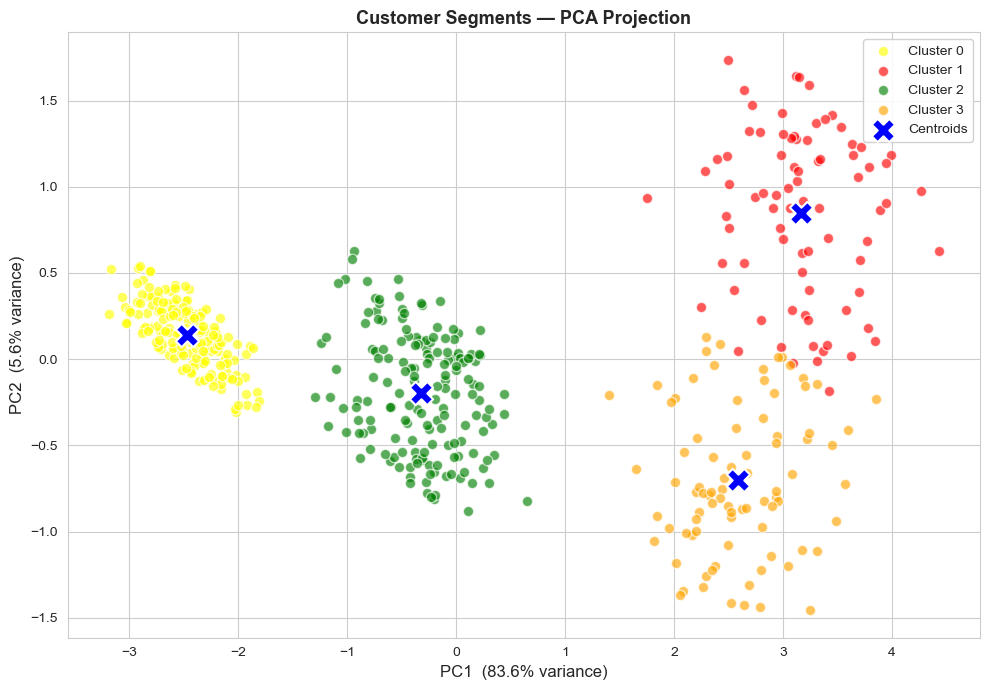

In [8]:
colours = ['yellow', 'Red', 'Green', 'Orange']

fig, ax = plt.subplots(figsize=(10, 7))

for c in range(K):
    mask = cluster_labels == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colours[c],
        label=f'Cluster {c}',
        alpha=0.65,
        edgecolors='white',
        s=55
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=280,
    c='blue', edgecolors='white',
    linewidth=1.5, label='Centroids', zorder=5
)

ax.set_xlabel(f'PC1  ({evr[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2  ({evr[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Customer Segments — PCA Projection',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.show()

### Cluster Visualisation — Observations

The scatter plot confirms that the four clusters are well separated
in PCA space, meaning K-Means found genuinely distinct groups rather
than arbitrary divisions.

Clusters 1 and 3 are on the right side of the chart. They are
separated vertically by PC2, which represents recency. Cluster 1
sits higher while Cluster 3 sits lower.

Cluster 0 sits on the far left, reflecting low spend and high
visit frequency — the young frequent browsers.

Cluster 2 sits in the middle, consistent with its role as the
average mainstream customer group.